# Split, validação cruzada e baselines de regressão

**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.

## Objetivo
Definir uma avaliação reproduzível para prever preços, reservar um teste final e medir referências simples com **validação cruzada temporal**, respeitando as datas e os imóveis repetidos.

A preparação das variáveis foi feita no notebook 03. Agora começamos a modelagem, usando as **18 características físicas originais** como referência comum. As variáveis derivadas e os indicadores demográficos serão comparados na etapa 05; não vamos testar todas as combinações neste notebook.

**Plano de execução:** três janelas de validação de 45 dias, três referências e **nove ajustes**, um por vez, com no máximo duas threads nas bibliotecas numéricas. Sem Optuna nesta etapa. A referência pela mediana não é um dos quatro algoritmos candidatos da etapa 05; ela estabelece um mínimo para comparação.

O cenário de avaliação será **vendas posteriores de imóveis não vistos no treino**. O histórico contém datas e IDs repetidos; uma divisão aleatória por linha pode misturar épocas e imóveis. Essa escolha não cobre todos os cenários possíveis: se o objetivo fosse prever revendas conhecidas ou regiões novas, precisaríamos de outro desenho.

**Limitação:** a EDA anterior examinou o histórico completo. O teste ficará reservado a partir desta etapa e não será usado para treinar, ajustar ou escolher modelos, mas não é um conjunto nunca observado durante a exploração.

**Execução:** selecione o Python da `.venv` e execute em ordem. O notebook usa apenas entradas históricas e identificação/alvo do notebook 03. Os exemplos futuros não participam da validação.

In [1]:
# Limita paralelismo antes de importar as bibliotecas numéricas.
import os
for nome_limite in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[nome_limite] = "2"

from pathlib import Path
from time import perf_counter
import hashlib
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import psutil
import sklearn
from IPython.display import display as exibir
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from threadpoolctl import threadpool_limits

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data" / "processed").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
PASTA_DADOS = PASTA_PROJETO / "data" / "processed"
PASTA_RESULTADOS = PASTA_PROJETO / "reports" / "metrics"
PASTA_GRAFICOS = PASTA_PROJETO / "reports" / "figures"
for pasta in [PASTA_RESULTADOS, PASTA_GRAFICOS]:
    pasta.mkdir(parents=True, exist_ok=True)

NUMERO_JANELAS = 3
DIAS_VALIDACAO = 45
PROPORCAO_TESTE = 0.20
LIMITE_THREADS = 2

recursos = {
    "cpus_logicas": psutil.cpu_count(),
    "ram_total_gib": round(psutil.virtual_memory().total / 2**30, 2),
    "ram_disponivel_gib": round(psutil.virtual_memory().available / 2**30, 2),
    "threads_numericas": LIMITE_THREADS,
    "ajustes_planejados": NUMERO_JANELAS * 3,
    "scikit_learn": sklearn.__version__,
}
exibir(pd.Series(recursos, name="valor").to_frame())

,valor
cpus_logicas,12
ram_total_gib,15.39
ram_disponivel_gib,6.51
threads_numericas,2
ajustes_planejados,9
scikit_learn,1.9.0


**O que o resultado mostra**

A tabela registra os recursos disponíveis no momento da execução, a versão da biblioteca e o orçamento de nove ajustes. Memória disponível varia conforme os outros programas abertos.

**Por que fizemos esta análise e o que decidimos**

O processamento será sequencial e usará modelos leves. O limite de threads reduz disputa de CPU; não é um limite rígido de RAM nem uma garantia de duração. A tabela histórica tem cerca de 21 mil linhas e o baseline usará apenas 18 entradas, com codificação esparsa do CEP.

## 1. Conferindo alinhamento entre entradas e preço

O arquivo de features não contém preço. Antes de separar os dados, precisamos garantir que cada linha ainda corresponde à mesma venda na tabela de identificação e alvo. Não basta os arquivos terem o mesmo tamanho.

In [2]:
# Confere esquema, origem e alinhamento das entradas históricas.
contrato = json.loads((PASTA_DADOS / "contrato_features.json").read_text(encoding="utf-8"))
variaveis = pd.read_csv(PASTA_DADOS / "features_historico.csv", dtype={"zipcode": "string"})
identificacao = pd.read_csv(PASTA_DADOS / "identificacao_alvo_historico.csv", dtype={"id": "string"})
historico_merge = pd.read_csv(PASTA_DADOS / "imoveis_com_demografia.csv",
                             dtype={"id": "string", "zipcode": "string"})
if hashlib.sha256((PASTA_DADOS / 'imoveis_com_demografia.csv').read_bytes()).hexdigest() != contrato['fontes_sha256']['imoveis_com_demografia.csv']:
    raise ValueError('O arquivo não corresponde ao hash registrado. Confira a origem dos dados ou artefatos.')
if variaveis.columns.tolist() != contrato['colunas_saida_ordenadas']:
    raise ValueError('Os nomes, a quantidade ou a ordem das colunas diferem do contrato esperado.')
if not (len(variaveis) == len(identificacao) == len(historico_merge)):
    raise ValueError('A quantidade de registros difere do esperado nesta etapa.')
if identificacao['linha_origem'].tolist() != list(range(len(variaveis))):
    raise ValueError('Os registros estão desalinhados; confira identificadores e ordem das linhas.')
pd.testing.assert_frame_equal(identificacao[["id", "date", "price"]], historico_merge[["id", "date", "price"]])
pd.testing.assert_frame_equal(
    variaveis[contrato["colunas_entrada_antes_derivadas"]],
    historico_merge[contrato["colunas_entrada_antes_derivadas"]],
    check_exact=False, rtol=1e-12, atol=1e-12,
)
datas = pd.to_datetime(identificacao["date"], format="%Y%m%dT%H%M%S", errors="coerce")
if not (datas.notna().all() and identificacao["id"].notna().all()):
    raise ValueError('Existem datas ou identificadores ausentes ou inválidos.')
colunas_baseline = contrato["grupos_candidatos"]["fisicas_originais"]
if not (len(colunas_baseline) == 18 and not {"id", "date", "price"} & set(colunas_baseline)):
    raise ValueError('Confira a separação de id, date e price: essas colunas não são entradas preditivas.')
exibir(pd.DataFrame({
    "verificacao": ["Linhas históricas alinhadas", "Entradas do baseline", "Datas inválidas",
                    "IDs com mais de uma venda"],
    "resultado": [len(variaveis), len(colunas_baseline), int(datas.isna().sum()),
                  int(identificacao["id"].value_counts().gt(1).sum())],
}))
del historico_merge

,verificacao,resultado
0,Linhas históricas alinhadas,21613
1,Entradas do baseline,18
2,Datas inválidas,0
3,IDs com mais de uma venda,176


**O que o resultado mostra**

O alinhamento é conferido pela posição, pelo conteúdo original de ID/data/preço e pelas 44 entradas anteriores às derivadas. As verificações também conferem a origem registrada no contrato.

**Por que fizemos esta análise e o que decidimos**

Um erro de alinhamento faria uma casa receber o preço de outra. Usamos as mesmas 18 características para todos os baselines, sem demografia ou derivadas, para estabelecer uma comparação inicial simples. As demais candidatas continuam disponíveis para o notebook 05.

## 2. Reservando o teste final

Ordenamos as vendas pelas datas e usamos a data na posição de aproximadamente 80% como início do teste. Todas as vendas do mesmo dia ficam juntas, por isso a proporção não será exata.

Se um imóvel do teste tiver vendas antigas, essas linhas antigas ficam separadas do conjunto de treino e validação. Não são apagadas da fonte. Essa regra representa o cenário de imóveis ainda não vistos; não é uma limpeza de outliers.

In [3]:
# Reserva as vendas recentes e separa ocorrências antigas dos mesmos imóveis.
datas_ordenadas = datas.sort_values()
data_corte = datas_ordenadas.iloc[int(len(datas_ordenadas) * (1 - PROPORCAO_TESTE))]
linhas_teste = datas.ge(data_corte)
ids_teste = set(identificacao.loc[linhas_teste, "id"])
linhas_separadas = ~linhas_teste & identificacao["id"].isin(ids_teste)
linhas_treino_validacao = ~linhas_teste & ~linhas_separadas

manifesto_split = pd.DataFrame({
    "source_row": identificacao["linha_origem"],
    "id": identificacao["id"],
    "date": datas.dt.strftime("%Y-%m-%d"),
    "partition": np.select([linhas_teste, linhas_separadas], ["test", "excluded_overlap"], default="train_validation"),
})
if not (linhas_teste.any() and linhas_treino_validacao.any()):
    raise ValueError('Treino, validação ou teste não possuem a quantidade mínima de registros.')
if not (datas[linhas_treino_validacao].max() < datas[linhas_teste].min()):
    raise ValueError('O treino deve terminar antes do início da validação ou do teste.')
if set(identificacao.loc[linhas_treino_validacao, 'id']) & ids_teste:
    raise ValueError('Há registros ou imóveis compartilhados entre partições que deveriam estar separadas.')
manifesto_split.to_csv(PASTA_DADOS / "split_manifest.csv", index=False)

# A partir daqui, preços usados em treinamento e métricas vêm só desta parcela.
posicoes_treino_validacao = (
    identificacao.loc[linhas_treino_validacao].assign(data_ordenacao=datas[linhas_treino_validacao])
    .sort_values(["data_ordenacao", "linha_origem"]).index.to_numpy()
)
entradas_cv = variaveis.loc[posicoes_treino_validacao, colunas_baseline].reset_index(drop=True)
precos_cv = identificacao.loc[posicoes_treino_validacao, "price"].reset_index(drop=True)
metadados_cv = identificacao.loc[posicoes_treino_validacao, ["linha_origem", "id"]].reset_index(drop=True)
metadados_cv["data"] = datas.loc[posicoes_treino_validacao].reset_index(drop=True)
if not (precos_cv.notna().all() and np.isfinite(precos_cv).all() and precos_cv.gt(0).all()):
    raise ValueError('Foram encontrados valores inválidos. Confira ausências, infinitos e limites antes de continuar.')
resumo_split = manifesto_split.groupby("partition").agg(
    registros=("source_row", "size"), inicio=("date", "min"), fim=("date", "max")
).rename(index={"train_validation": "Treino e validação", "test": "Teste final",
                "excluded_overlap": "Vendas antigas separadas"})
exibir(resumo_split)

,registros,inicio,fim
partition,,,
Vendas antigas separadas,91,2014-05-05,2015-02-27
Teste final,4331,2015-03-10,2015-05-27
Treino e validação,17191,2014-05-02,2015-03-09


**O que o resultado mostra**

O corte em 10/03/2015 reservou 4.331 vendas para teste e manteve 17.191 para treino e validação. Outras 91 vendas anteriores foram separadas porque os mesmos imóveis aparecem no teste. O quadro mostra os períodos de cada grupo. A data do corte depende apenas das datas, não dos preços ou do desempenho de algum modelo.

**Por que fizemos esta análise e o que decidimos**

A partir deste ponto, treino e métricas usam somente `entradas_cv` e `precos_cv`. O notebook não calcula métricas do teste. Guardamos um manifesto com a linha original para reutilizar a divisão na etapa 05 e na avaliação final. A EDA já viu o histórico completo, limitação explicitada na abertura.

## 3. Cross-validation temporal: três tentativas em períodos diferentes

**Cross-validation**, ou validação cruzada, repete a avaliação em divisões diferentes. Aqui não embaralhamos as vendas:

1. Treinar no início do histórico e validar nos 45 dias seguintes.
2. Ampliar o treino com o período já passado e validar nos próximos 45 dias.
3. Ampliar novamente o treino e validar nos últimos 45 dias anteriores ao teste.

Uma venda usada para validar na primeira janela pode entrar no treino da segunda: nesse novo momento ela já é passado. Dentro de cada janela, nenhum ID pode aparecer em treino e validação. O teste final fica fora de todas as janelas.

Usamos `TimeSeriesSplit` sobre um **calendário diário completo**, não diretamente sobre linhas de vendas. Isso mantém duração igual de validação mesmo com quantidade diferente de transações por dia, conforme a preocupação com espaçamento da [documentação do scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).

Não adicionamos um intervalo vazio entre treino e validação nesta versão: não há atraso de disponibilidade dos preços documentado. Se houver atraso real, o protocolo deverá incorporar esse intervalo.

In [4]:
# Cria janelas no calendário e converte os dias em índices das vendas.
calendario = pd.date_range(metadados_cv["data"].min(), metadados_cv["data"].max(), freq="D")
divisor_temporal = TimeSeriesSplit(n_splits=NUMERO_JANELAS, test_size=DIAS_VALIDACAO)
particoes_cv = []
resumo_janelas = []
registros_particoes = []
for numero_janela, (dias_treino, dias_validacao) in enumerate(divisor_temporal.split(calendario), start=1):
    inicio_validacao = calendario[dias_validacao[0]]
    fim_validacao = calendario[dias_validacao[-1]]
    mascara_validacao = metadados_cv["data"].between(inicio_validacao, fim_validacao)
    mascara_treino_inicial = metadados_cv["data"].le(calendario[dias_treino[-1]])
    ids_validacao = set(metadados_cv.loc[mascara_validacao, "id"])
    mascara_sobreposicao = mascara_treino_inicial & metadados_cv["id"].isin(ids_validacao)
    mascara_treino = mascara_treino_inicial & ~mascara_sobreposicao
    indices_treino = np.flatnonzero(mascara_treino)
    indices_validacao = np.flatnonzero(mascara_validacao)

    if not (len(indices_treino) > 0 and len(indices_validacao) > 1):
        raise ValueError('Treino, validação ou teste não possuem a quantidade mínima de registros.')
    if not (metadados_cv.loc[indices_treino, "data"].max() < metadados_cv.loc[indices_validacao, "data"].min()):
        raise ValueError('O treino deve terminar antes do início da validação ou do teste.')
    if set(metadados_cv.loc[indices_treino, 'id']) & ids_validacao:
        raise ValueError('Há registros ou imóveis compartilhados entre partições que deveriam estar separadas.')
    if set(metadados_cv.loc[np.r_[indices_treino, indices_validacao], 'id']) & ids_teste:
        raise ValueError('Há registros ou imóveis compartilhados entre partições que deveriam estar separadas.')
    particoes_cv.append((indices_treino, indices_validacao))
    resumo_janelas.append({
        "janela": numero_janela,
        "treino_inicio": metadados_cv.loc[indices_treino, "data"].min(),
        "treino_fim": metadados_cv.loc[indices_treino, "data"].max(),
        "validacao_inicio": inicio_validacao, "validacao_fim": fim_validacao,
        "dias_validacao": len(dias_validacao),
        "registros_treino": len(indices_treino), "registros_validacao": len(indices_validacao),
        "vendas_antigas_separadas": int(mascara_sobreposicao.sum()),
        "ceps_desconhecidos_validacao": len(set(entradas_cv.loc[indices_validacao, "zipcode"]) - set(entradas_cv.loc[indices_treino, "zipcode"])),
    })
    for papel, mascara in [("train", mascara_treino), ("validation", mascara_validacao),
                           ("excluded_overlap", mascara_sobreposicao)]:
        registro = metadados_cv.loc[mascara, ["linha_origem"]].rename(columns={"linha_origem": "source_row"})
        registro = registro.assign(fold=numero_janela, role=papel)
        registros_particoes.append(registro)

resumo_janelas = pd.DataFrame(resumo_janelas)
manifesto_cv = pd.concat(registros_particoes, ignore_index=True)
if manifesto_cv.query("role == 'validation'")['source_row'].duplicated().any():
    raise ValueError('Foram encontradas duplicidades onde registros ou nomes deveriam ser únicos.')
if set(manifesto_cv['source_row']) & set(manifesto_split.loc[linhas_teste, 'source_row']):
    raise ValueError('Há registros ou imóveis compartilhados entre partições que deveriam estar separadas.')
resumo_janelas.to_csv(PASTA_RESULTADOS / "baseline_cv_janelas.csv", index=False)
manifesto_cv.to_csv(PASTA_DADOS / "cv_manifest.csv", index=False)
exibir(resumo_janelas)

,janela,treino_inicio,treino_fim,validacao_inicio,validacao_fim,dias_validacao,registros_treino,registros_validacao,vendas_antigas_separadas,ceps_desconhecidos_validacao
0,1,2014-05-02,2014-10-25,2014-10-26,2014-12-09,45,11241,2392,15,0
1,2,2014-05-02,2014-12-09,2014-12-10,2015-01-23,45,13626,1626,22,0
2,3,2014-05-02,2015-01-23,2015-01-24,2015-03-09,45,15235,1917,39,0


**O que o resultado mostra**

As validações cobrem 26/10–09/12/2014, 10/12/2014–23/01/2015 e 24/01–09/03/2015. Elas contêm 2.392, 1.626 e 1.917 vendas. Foram retiradas de cada treino 15, 22 e 39 vendas antigas com ID compartilhado com a respectiva validação. Nenhum CEP das validações era desconhecido naquele treino. Cada linha descreve uma avaliação completa: período de treino, 45 dias de validação, número de vendas e exclusões por ID compartilhado. As quantidades de vendas variam mesmo com duração igual.

**Por que fizemos esta análise e o que decidimos**

Três janelas são um compromisso entre observar estabilidade e limitar custo. É validação cruzada de verdade: cada modelo será ajustado do zero em cada treino e avaliado na janela correspondente. Não usamos KFold aleatório porque ele poderia misturar épocas e causar dataleakage; apenas agrupar por ID também não garantiria ordem temporal.

**Hipótese**

Se o erro variar muito entre janelas, composição das casas, mudança de período ou tamanho do treino podem estar envolvidos. Três janelas sobre um histórico curto não comprovam estabilidade de longo prazo.

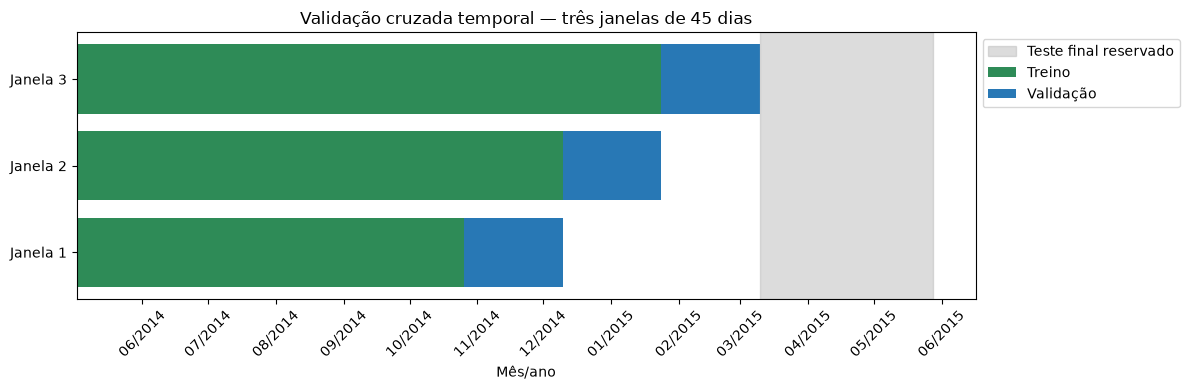

In [5]:
# Desenha a sequência temporal com treino crescente e validações posteriores.
figura, eixo = plt.subplots(figsize=(12, 4))
for linha in resumo_janelas.itertuples(index=False):
    inicio_treino = mdates.date2num(linha.treino_inicio)
    fim_treino = mdates.date2num(linha.treino_fim + pd.Timedelta(days=1))
    inicio_validacao = mdates.date2num(linha.validacao_inicio)
    eixo.barh(linha.janela, fim_treino - inicio_treino, left=inicio_treino, color="#2E8B57", label="Treino" if linha.janela == 1 else None)
    eixo.barh(linha.janela, DIAS_VALIDACAO, left=inicio_validacao, color="#2878B5", label="Validação" if linha.janela == 1 else None)
eixo.axvspan(data_corte, datas.max() + pd.Timedelta(days=1), color="#BBBBBB", alpha=0.5, label="Teste final reservado")
eixo.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
eixo.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
eixo.set_yticks([1, 2, 3], ["Janela 1", "Janela 2", "Janela 3"])
eixo.set(xlabel="Mês/ano", title="Validação cruzada temporal — três janelas de 45 dias")
eixo.tick_params(axis="x", rotation=45)
eixo.grid(False)
eixo.legend(loc="upper left", bbox_to_anchor=(1, 1))
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "baseline_cv_temporal.png", dpi=150)
plt.show()

**O que o resultado mostra**

Verde representa o intervalo de treino e azul a validação posterior. A região cinza mostra o teste final, fora das três avaliações. As barras representam períodos, não a quantidade de registros.

**Por que fizemos esta análise e o que decidimos**

A figura facilita explicar a sequência sem ler índices. As vendas antigas retiradas por sobreposição de ID estão contabilizadas na tabela, mas não aparecem como buracos nas barras. O treinamento pode crescer a cada janela sem consultar datas futuras.

## 4. Pipeline e referências simples

**Mediana:** prevê para todas as casas o preço mediano aprendido apenas no treino da janela. É uma referência mínima.

**Regressão linear:** aprende uma combinação das entradas para estimar preço.

**Ridge:** é uma regressão linear com penalização dos coeficientes. Usaremos `alpha=1.0` fixo como referência, sem procurar o melhor valor. Áreas relacionadas podem repetir informação, e essa penalização é uma alternativa a investigar.

Os dois modelos recebem o mesmo tratamento: preencher números pela mediana do treino, padronizar números e codificar CEP por categorias. O CEP desconhecido não causa erro, mas ficará sem uma categoria própria aprendida. O pipeline inteiro será recriado a cada janela, evitando compartilhar estatísticas entre treino e validação.

In [6]:
# Define o pré-processamento sem ajustá-lo aos dados nesta célula.
colunas_categoricas = ["zipcode"]
colunas_numericas = [coluna for coluna in colunas_baseline if coluna not in colunas_categoricas]
tratamento_numerico = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escala", StandardScaler()),
])
tratamento_categorico = Pipeline([
    ("imputacao", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("codificacao", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True)),
])
preparacao = ColumnTransformer([
    ("numericas", tratamento_numerico, colunas_numericas),
    ("categoricas", tratamento_categorico, colunas_categoricas),
], sparse_threshold=1.0, n_jobs=1)

referencias = {
    "Mediana": DummyRegressor(strategy="median"),
    "Regressão linear": Pipeline([
        ("preparacao", clone(preparacao)),
        ("modelo", LinearRegression(n_jobs=1, tol=1e-6)),
    ]),
    "Ridge": Pipeline([
        ("preparacao", clone(preparacao)),
        ("modelo", Ridge(alpha=1.0, solver="lsqr", tol=1e-6)),
    ]),
}
exibir(pd.DataFrame([
    {"referencia": nome, "janelas": NUMERO_JANELAS, "ajustes": NUMERO_JANELAS,
     "entradas": "nenhuma relação aprendida com features" if nome == "Mediana" else "18 características físicas",
     "configuracao": "mediana do treino" if nome == "Mediana" else
                     ("coeficientes sem penalização" if nome == "Regressão linear" else "alpha=1.0 fixo")}
    for nome in referencias
]))

,referencia,janelas,ajustes,entradas,configuracao
0,Mediana,3,3,nenhuma relação aprendida com features,mediana do treino
1,Regressão linear,3,3,18 características físicas,coeficientes sem penalização
2,Ridge,3,3,18 características físicas,alpha=1.0 fixo


**O que o resultado mostra**

Foram definidas três referências e três janelas para cada uma, totalizando nove ajustes. O código desta célula só configura os modelos; o aprendizado ocorre na próxima seção.

**Por que fizemos esta análise e o que decidimos**

A matriz categórica é esparsa e os experimentos não são paralelos. A mediana usa uma entrada constante, pois sua previsão depende somente dos preços de treino. Os algoritmos adicionais e a comparação de features ficam para a etapa 05; esses três nomes não representam a escolha final dos quatro candidatos.

**Hipótese**

Ridge pode produzir resultados mais estáveis diante de entradas correlacionadas, mas esse efeito depende da penalização. Um resultado similar entre linear e Ridge com alpha fixo não encerra essa investigação.

## 5. Medindo cada janela sem tocar no teste

**MAE** é o erro absoluto médio, na unidade do preço: quanto as previsões se afastam do valor real, em média. Será a métrica principal.

**RMSE** dá maior peso aos erros grandes. 

**R²** compara os erros quadráticos com a variação dos preços na janela; pode ser negativo e não é percentual de acerto.

Não cortaremos previsões negativas nem preços extremos nesta referência: registraremos esses casos para investigar. O preço permanece na escala original. Os tempos medidos incluem treino e previsão; a memória registrada é a memória do processo Python observada entre etapas, não um pico exato nem a memória total da máquina.

In [7]:
# Executa nove ajustes sequenciais com novas cópias dos modelos em cada janela.
resultados = []
previsoes_validacao = []
processo = psutil.Process()
inicio_execucao = perf_counter()
maior_memoria_observada_mib = processo.memory_info().rss / 2**20

with threadpool_limits(limits=LIMITE_THREADS):
    for nome_modelo, referencia in referencias.items():
        for numero_janela, (indices_treino, indices_validacao) in enumerate(particoes_cv, start=1):
            inicio_ajuste = perf_counter()
            modelo = clone(referencia)
            entradas_treino = entradas_cv.iloc[indices_treino]
            entradas_validacao = entradas_cv.iloc[indices_validacao]
            alvo_treino = precos_cv.iloc[indices_treino]
            alvo_validacao = precos_cv.iloc[indices_validacao]

            # A referência pela mediana não utiliza as características.
            if nome_modelo == "Mediana":
                dados_treino_modelo = np.zeros((len(indices_treino), 1))
                dados_validacao_modelo = np.zeros((len(indices_validacao), 1))
            else:
                dados_treino_modelo = entradas_treino
                dados_validacao_modelo = entradas_validacao

            modelo.fit(dados_treino_modelo, alvo_treino)
            previsto = modelo.predict(dados_validacao_modelo)
            previsto_treino = modelo.predict(dados_treino_modelo)
            if not (np.isfinite(previsto).all()):
                raise ValueError('Foram encontrados valores inválidos. Confira ausências, infinitos e limites antes de continuar.')
            resultados.append({
                "modelo": nome_modelo, "janela": numero_janela,
                "mae": mean_absolute_error(alvo_validacao, previsto),
                "rmse": root_mean_squared_error(alvo_validacao, previsto),
                "r2": r2_score(alvo_validacao, previsto),
                "mae_treino": mean_absolute_error(alvo_treino, previsto_treino),
                "previsoes_nao_positivas": int((previsto <= 0).sum()),
                "segundos": perf_counter() - inicio_ajuste,
                "n_treino": len(indices_treino), "n_validacao": len(indices_validacao),
            })
            previsoes_validacao.append(pd.DataFrame({
                "source_row": metadados_cv.loc[indices_validacao, "linha_origem"].to_numpy(),
                "modelo": nome_modelo, "janela": numero_janela,
                "preco_real": alvo_validacao.to_numpy(), "preco_previsto": previsto,
            }))
            maior_memoria_observada_mib = max(maior_memoria_observada_mib, processo.memory_info().rss / 2**20)
            print(f"{nome_modelo} | janela {numero_janela}: concluída", flush=True)
            del modelo
        gc.collect()

tempo_total_segundos = perf_counter() - inicio_execucao
resultados = pd.DataFrame(resultados)
previsoes_validacao = pd.concat(previsoes_validacao, ignore_index=True)
resultados.to_csv(PASTA_RESULTADOS / "baseline_cv_resultados.csv", index=False)
previsoes_validacao.to_csv(PASTA_RESULTADOS / "baseline_cv_previsoes.csv", index=False)
exibir(resultados.round(3))

Mediana | janela 1: concluída
Mediana | janela 2: concluída
Mediana | janela 3: concluída
Regressão linear | janela 1: concluída
Regressão linear | janela 2: concluída
Regressão linear | janela 3: concluída
Ridge | janela 1: concluída
Ridge | janela 2: concluída
Ridge | janela 3: concluída


,modelo,janela,mae,rmse,r2,mae_treino,previsoes_nao_positivas,segundos,n_treino,n_validacao
0,Mediana,1,217399.752,360307.121,-0.043,222565.487,0,0.023,11241,2392
1,Mediana,2,219376.582,362340.437,-0.040,221711.613,0,0.005,13626,1626
2,Mediana,3,217633.650,357215.447,-0.041,221434.345,0,0.004,15235,1917
3,Regressão linear,1,96327.363,153643.479,0.810,93921.002,7,0.081,11241,2392
4,Regressão linear,2,97040.960,151775.664,0.818,94046.381,6,0.102,13626,1626
5,Regressão linear,3,98487.599,155240.618,0.803,94011.460,8,0.103,15235,1917
6,Ridge,1,96528.201,153569.570,0.811,94207.517,6,0.088,11241,2392
7,Ridge,2,97160.990,151803.354,0.817,94297.875,6,0.090,13626,1626
8,Ridge,3,98344.943,154878.996,0.804,94244.890,8,0.097,15235,1917


**O que o resultado mostra**

O MAE da regressão linear ficou entre aproximadamente 96 mil e 98,5 mil nas três janelas, contra cerca de 217 mil a 219 mil da mediana. Nas 5.935 vendas validadas, houve 21 previsões não positivas na regressão linear e 20 em Ridge; esses erros não foram ocultados nem corrigidos nas métricas. Cada linha traz uma referência em um período. São previsões de validação feitas por modelos que não treinaram nessas linhas nem em outros registros dos mesmos imóveis naquele treino.

**Por que fizemos esta análise e o que decidimos**

A tabela permite identificar variação temporal, diferença entre erro de treino e validação e previsões incompatíveis com preços positivos. Os modelos de cada janela foram descartados após registrar as previsões; não exportamos um modelo de produção nem fizemos ajuste adicional sobre todos os dados.

In [8]:
# Resume as métricas dando o mesmo peso às três janelas temporais.
resumo_resultados = resultados.groupby("modelo").agg(
    mae_medio=("mae", "mean"), mae_desvio=("mae", "std"),
    rmse_medio=("rmse", "mean"), r2_medio=("r2", "mean"),
    mae_treino_medio=("mae_treino", "mean"),
    segundos_totais=("segundos", "sum"),
    previsoes_nao_positivas=("previsoes_nao_positivas", "sum"),
).sort_values("mae_medio")
mae_referencia = resumo_resultados.loc["Mediana", "mae_medio"]
resumo_resultados["reducao_mae_vs_mediana_pct"] = (1 - resumo_resultados["mae_medio"] / mae_referencia) * 100

# Calcula também o MAE por todas as vendas de validação, com peso por venda.
previsoes_validacao["erro_absoluto"] = (
    previsoes_validacao["preco_real"] - previsoes_validacao["preco_previsto"]
).abs()
resumo_resultados["mae_por_venda_validada"] = previsoes_validacao.groupby("modelo")["erro_absoluto"].mean()
resumo_resultados.to_csv(PASTA_RESULTADOS / "baseline_cv_resumo.csv")
exibir(resumo_resultados.round(3))

,mae_medio,mae_desvio,rmse_medio,r2_medio,mae_treino_medio,segundos_totais,previsoes_nao_positivas,reducao_mae_vs_mediana_pct,mae_por_venda_validada
modelo,,,,,,,,,
Regressão linear,97285.307,1100.652,153553.254,0.810,93992.948,0.286,21,55.402,97220.620
Ridge,97344.711,922.200,153417.307,0.811,94250.094,0.274,20,55.374,97288.371
Mediana,218136.661,1080.152,359954.335,-0.041,221903.815,0.032,0,0.000,218016.889


**O que o resultado mostra**

A regressão linear obteve MAE médio de 97.285,31, Ridge de 97.344,71 e a mediana de 218.136,66. A redução do erro frente à mediana foi cerca de 55,4%. A diferença de aproximadamente 59 unidades entre os dois modelos lineares é pequena frente à variação temporal observada; não demonstra superioridade ampla. `mae_medio` dá peso igual às três janelas de 45 dias. `mae_por_venda_validada` reúne todas as vendas validadas, dando mais peso à janela com mais transações. O desvio informa a variação do MAE entre períodos; não é um intervalo de confiança.

**Por que fizemos esta análise e o que decidimos**

Comparar com a mediana mostra quanto um modelo simples melhora a referência constante. O menor erro nesta etapa é apenas uma referência provisória, não a escolha do modelo final. R² médio não significa percentual de previsões corretas, e diferença pequena entre algoritmos não justifica afirmar superioridade ampla.

**Hipótese**

Se os modelos lineares superarem a mediana mas mantiverem erros grandes em algumas casas, relações não lineares ou variáveis adicionais podem ajudar. O notebook 05 deverá avaliar isso com as mesmas partições.

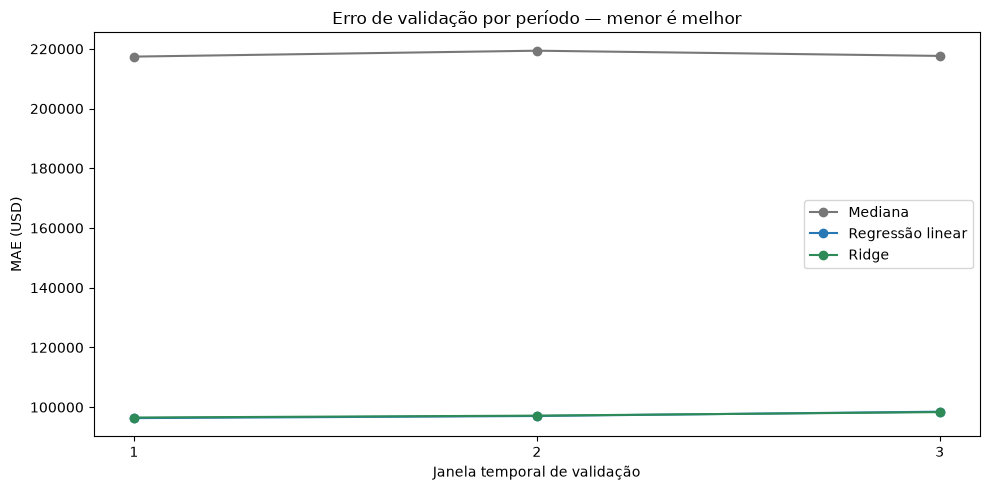

In [9]:
# Mostra os erros por período para não esconder variações na média.
figura, eixo = plt.subplots(figsize=(10, 5))
cores = {"Mediana": "#777777", "Regressão linear": "#2878B5", "Ridge": "#2E8B57"}
for nome_modelo, tabela in resultados.groupby("modelo", sort=False):
    eixo.plot(tabela["janela"], tabela["mae"], marker="o", label=nome_modelo, color=cores[nome_modelo])
eixo.set_xticks([1, 2, 3])
eixo.set(xlabel="Janela temporal de validação", ylabel="MAE (USD)",
         title="Erro de validação por período — menor é melhor")
eixo.ticklabel_format(axis="y", style="plain")
eixo.grid(False)
eixo.legend()
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "baseline_mae_por_janela.png", dpi=150)
plt.show()

**O que o resultado mostra**

Os dois modelos lineares ficaram próximos e abaixo da mediana nas três janelas. Seu MAE aumentou modestamente na última janela, mesmo com mais dados de treino. O gráfico compara as referências nos mesmos períodos. Uma linha mais baixa indica menor erro absoluto médio naquela janela. Variação entre janelas pode ocorrer mesmo sem mudar o algoritmo.

**Por que fizemos esta análise e o que decidimos**

A evolução evita esconder instabilidade dentro de uma média. Não interpretaremos a curva como prova de tendência do mercado: treino crescente e mudanças na composição das casas também podem alterar o erro.

## 6. Salvando o protocolo para a próxima etapa

O notebook 05 deverá reutilizar os manifestos de teste e de validação, os mesmos índices originais e o critério de MAE médio por janela. Dessa forma, as comparações com novas features e modelos serão coerentes. O teste final só receberá métricas na etapa 06.

In [10]:
# Registra regras, fontes, configurações e custo observado.
arquivos_fontes = ["features_historico.csv", "identificacao_alvo_historico.csv", "contrato_features.json"]
protocolo = {
    "versao": "temporal_cv_v1",
    "cenario": "vendas_posteriores_de_imoveis_nao_vistos",
    "test_cutoff": data_corte.strftime("%Y-%m-%d"),
    "split_counts": {str(grupo): int(quantidade) for grupo, quantidade in manifesto_split["partition"].value_counts().items()},
    "cv": {"strategy": "TimeSeriesSplit_on_daily_calendar_with_id_overlap_removal",
           "n_splits": NUMERO_JANELAS, "validation_days": DIAS_VALIDACAO,
           "gap_days": 0, "gap_assumption": "atraso_de_disponibilidade_do_preco_nao_documentado"},
    "features": colunas_baseline,
    "primary_metric": "mean_fold_mae",
    "baseline_parameters": {"linear_tol": 1e-6, "ridge_alpha": 1.0, "ridge_solver": "lsqr", "ridge_tol": 1e-6},
    "resources": {**recursos, "fits_completed": len(resultados), "execution_seconds": tempo_total_segundos,
                  "max_observed_python_rss_mib": maior_memoria_observada_mib,
                  "memory_note": "amostras entre etapas, não pico exato"},
    "test_evaluated": False,
    "limitations": ["EDA anterior examinou todo o histórico", "histórico curto",
                    "data dos exemplos futuros desconhecida", "sem avaliação de regiões inteiramente novas"],
    "source_sha256": {
        nome: hashlib.sha256((PASTA_DADOS / nome).read_bytes()).hexdigest() for nome in arquivos_fontes
    },
    "split_manifest": "data/processed/split_manifest.csv",
    "cv_manifest": "data/processed/cv_manifest.csv",
}
(PASTA_RESULTADOS / "baseline_protocolo.json").write_text(
    json.dumps(protocolo, indent=2, ensure_ascii=False), encoding="utf-8"
)
exibir(pd.DataFrame({
    "item": ["Ajustes concluídos", "Tempo total dos experimentos (s)",
             "Maior memória Python observada (MiB)", "Teste final avaliado", "Modelos finais publicados"],
    "valor": [len(resultados), round(tempo_total_segundos, 2),
              round(maior_memoria_observada_mib, 2), False, 0],
}))

,item,valor
0,Ajustes concluídos,9
1,Tempo total dos experimentos (s),0.88
2,Maior memória Python observada (MiB),227.58
3,Teste final avaliado,False
4,Modelos finais publicados,0


**O que o resultado mostra**

O relatório registra tempo e memória observados para os nove ajustes. Ele confirma que não houve avaliação do teste nem publicação de modelo final.

**Por que fizemos esta análise e o que decidimos**

As métricas de recursos pertencem a esta execução local e não são garantia para modelos maiores. A etapa 05 terá orçamento próprio, definido a partir dessas medidas. A lista de índices permite reutilizar a validação sem refazer decisões a partir dos resultados do teste.

## Complemento: MAPE na validação

Objetivo: expressar o erro em percentual sem alterar o critério de escolha.

In [11]:
# Mede erro relativo nas previsões já salvas, sem ajustar modelos.
previsoes_mape = pd.read_csv(PASTA_RESULTADOS / "baseline_cv_previsoes.csv")
if "modelo" not in previsoes_mape:
    previsoes_mape["modelo"] = json.loads(
        (PASTA_RESULTADOS.parent.parent / "artifacts/configuracao_modelo_selecionado.json").read_text(encoding="utf-8")
    )["modelo"]
if (not np.isfinite(previsoes_mape[["preco_real", "preco_previsto"]]).all().all()
        or not previsoes_mape["preco_real"].gt(0).all()):
    raise ValueError("MAPE exige preços reais positivos e previsões finitas.")
previsoes_mape["erro_percentual"] = (
    100 * (previsoes_mape["preco_previsto"] - previsoes_mape["preco_real"]).abs()
    / previsoes_mape["preco_real"]
)
mape_janelas = previsoes_mape.groupby(["modelo", "janela"], as_index=False).agg(
    MAPE_pct=("erro_percentual", "mean"), vendas=("source_row", "size")
)
# Distingue peso igual por janela de peso igual por venda.
mape_resumo = mape_janelas.groupby("modelo", as_index=False).agg(
    MAPE_medio_janelas_pct=("MAPE_pct", "mean")
).merge(previsoes_mape.groupby("modelo", as_index=False).agg(
    MAPE_todas_vendas_pct=("erro_percentual", "mean")
), on="modelo", validate="one_to_one")
mape_janelas.to_csv(PASTA_RESULTADOS / "baseline_mape_janelas.csv", index=False)
mape_resumo.to_csv(PASTA_RESULTADOS / "baseline_mape_resumo.csv", index=False)
exibir(mape_janelas.round(2))
exibir(mape_resumo.round(2))


,modelo,janela,MAPE_pct,vendas
0,Mediana,1,43.44,2392
1,Mediana,2,44.69,1626
2,Mediana,3,45.00,1917
3,Regressão linear,1,20.23,2392
4,Regressão linear,2,20.69,1626
5,Regressão linear,3,21.75,1917
6,Ridge,1,20.27,2392
7,Ridge,2,20.70,1626
8,Ridge,3,21.69,1917


,modelo,MAPE_medio_janelas_pct,MAPE_todas_vendas_pct
0,Mediana,44.38,44.29
1,Regressão linear,20.89,20.85
2,Ridge,20.89,20.85


**O que o resultado mostra:** MAPE médio das janelas — Mediana: 44,38%; Regressão linear: 20,89%; Ridge: 20,89%.

**Por que medir:** calculamos o erro absoluto dividido pelo preço real de cada venda, multiplicamos por 100 e tiramos a média. Assim, o erro pode ser comunicado em percentual, complementando o MAE em USD.

A primeira tabela detalha cada janela. A segunda distingue média com peso igual por janela de média com peso igual por venda; os resultados podem diferir porque as janelas têm quantidades diferentes de vendas. MAPE não é o erro percentual mediano nem MAE dividido pelo preço médio.

**Decisão:** manter MAE como critério de seleção e usar MAPE para interpretação. Para o mesmo erro em dólares, imóveis mais baratos recebem maior peso relativo. Preços próximos de zero podem distorcer a métrica; os casos não são removidos silenciosamente. Esta inclusão não representa nova seleção ou nova avaliação independente.

## Conclusão e hipóteses para investigar

Foi estabelecida uma validação cruzada temporal com três janelas, controle de imóveis repetidos e teste final separado. Os modelos são referências simples, usando as mesmas 18 características originais.

**Hipótese:** variáveis derivadas e demografia elegível podem reduzir o erro. Avaliar no notebook 05 mantendo partições e métricas iguais.

**Hipótese:** modelos não lineares podem representar melhor interações entre localização, área e padrão construtivo. Comparar os quatro candidatos; não usar Optuna antes da comparação inicial.

**Próximo passo:** seleção de modelos e investigação das features no notebook 05. O teste final permanece reservado e não deve orientar essa escolha.

**Resultados desta execução:** regressão linear e Ridge reduziram o MAE em aproximadamente 55,4% frente à mediana, mas produziram 21 e 20 previsões não positivas, respectivamente. O teste final não foi avaliado.

**Hipótese:** transformação do alvo ou modelos não lineares podem ajudar a evitar previsões incompatíveis com preços e reduzir erros grandes. Avaliar isso na validação antes de definir o modelo final.